<a href="https://colab.research.google.com/github/SanaAlotaibi/DataScienceProject/blob/main/IT362_phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Science Project Phase 2

Data Processing, Cleaning, and Exploratory Data Analysis (EDA)

## Dataset information preview

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import warnings
from pandas.errors import DtypeWarning

# Ignore DtypeWarning
warnings.filterwarnings('ignore', category=DtypeWarning)

# Columns you want to keep
columns_to_keep = [
    "name", "owner", "url", "description", "stars", "forks",
    "created_at", "pushed_at", "primary_language", "all_languages_bytes",
    "topics", "contributors_count"
]

# Load the dataset and select specified columns
df = pd.read_csv('collectedData.csv')[columns_to_keep]


# === BASIC INFO ===
attribute_informations = pd.DataFrame({
    'AttributeName' : df.columns,
    'DataType' : df.dtypes.values
})

print(f"Number of attributes: {len(df.columns)}")
print(f"Number of objects: {len(df)}")
print("\nAttributes and Their Types:")
print(attribute_informations)

# Preview
df.head()

Number of attributes: 12
Number of objects: 5751

Attributes and Their Types:
          AttributeName DataType
0                  name   object
1                 owner   object
2                   url   object
3           description   object
4                 stars   object
5                 forks   object
6            created_at   object
7             pushed_at   object
8      primary_language   object
9   all_languages_bytes   object
10               topics   object
11   contributors_count   object


,name,owner,url,description,stars,forks,created_at,pushed_at,primary_language,all_languages_bytes,topics,contributors_count
0,DeepSpeed,deepspeedai,https://github.com/deepspeedai/DeepSpeed,DeepSpeed is a deep learning optimization libr...,40213,4564,2020-01-23T18:35:18Z,2025-09-25T00:42:02Z,Python,"{'Python': 5912469, 'C++': 1505585, 'Cuda': 71...","deep-learning, pytorch, gpu, machine-learning,...",1
1,EasyOCR,JaidedAI,https://github.com/JaidedAI/EasyOCR,Ready-to-use OCR with 80+ supported languages ...,28016,3470,2020-03-14T11:46:39Z,2024-09-24T11:24:36Z,Python,"{'Python': 633819, 'C++': 112732, 'Cuda': 5825...","ocr, deep-learning, crnn, pytorch, lstm, machi...",1
2,fastbook,fastai,https://github.com/fastai/fastbook,"The fastai book, published as Jupyter Notebooks",23807,9161,2020-02-28T19:26:47Z,2024-08-16T14:38:24Z,Jupyter Notebook,"{'Jupyter Notebook': 8892620, 'Python': 5190}","notebooks, fastai, deep-learning, machine-lear...",1
3,serve,jina-ai,https://github.com/jina-ai/serve,☁️ Build multimodal AI applications with cloud...,21746,2236,2020-02-13T17:04:44Z,2025-03-24T13:59:54Z,Python,"{'Python': 2806034, 'Go': 46933, 'Shell': 2394...","neural-search, cloud-native, deep-learning, ma...",1
4,CVPR2025-Papers-with-Code,amusi,https://github.com/amusi/CVPR2025-Papers-with-...,CVPR 2025 论文和开源项目合集,20970,2740,2020-02-26T06:04:25Z,2025-07-02T08:28:29Z,NaN,{},"cvpr, cvpr2020, computer-vision, deep-learning...",1


## Dataset quality check

### Check if data is enough (sample size adequacy)

In [ ]:
# We'll compute the required sample size for 95% confidence, 5% margin of error.
# Formula: n = (Z^2 * p * (1-p)) / e^2
# Assuming p = 0.5 (maximum variability) and Z = 1.96 for 95% confidence.

Z = 1.96
p = 0.5
e = 0.05

required_n = (Z**2 * p * (1 - p)) / (e**2)
collected_n = len(df)

print(f"Required sample size: {required_n:.0f}")
print(f"Collected observations: {collected_n}")
if collected_n >= required_n:
    print("The collected data size is statistically sufficient.")
else:
    print("The dataset may be smaller than the recommended sample size.")

Required sample size: 384
Collected observations: 5751
The collected data size is statistically sufficient.


### Check for duplicates and missing values

In [ ]:
print("\nMissing values per column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

# Clean dataset
df_cleaned = df.dropna(subset=['primary_language']).drop_duplicates()

# Define numeric columns for later preprocessing
numeric_cols = ['stars', 'forks', 'contributors_count']

print("\nOriginal DataFrame shape:", df.shape)
print("Cleaned DataFrame shape:", df_cleaned.shape)

df_cleaned.to_csv('CleanedDataset.csv', index=False)


Missing values per column:
name                      0
owner                     0
url                       0
description             115
stars                     3
forks                     4
created_at                3
pushed_at                 5
primary_language        642
all_languages_bytes       5
topics                 1099
contributors_count        5
dtype: int64

Number of duplicate rows:
0

Original DataFrame shape: (5751, 12)
Cleaned DataFrame shape: (5109, 12)


After checking our dataset quality we only removed rows that miss primary language attribute.

## Data preprocessing

### Transforming

In [ ]:
import numpy as np

# Convert 'stars', 'forks' and 'contributors_count' columns to numeric, coercing errors
df_cleaned['stars'] = pd.to_numeric(df_cleaned['stars'], errors='coerce')
df_cleaned['forks'] = pd.to_numeric(df_cleaned['forks'], errors='coerce')
df_cleaned['contributors_count'] = pd.to_numeric(df_cleaned['contributors_count'], errors='coerce')

# Fill missing numeric values with median
df_cleaned[numeric_cols] = df_cleaned[numeric_cols].fillna(df_cleaned[numeric_cols].median())

# Handle outliers
df_cleaned['stars_log'] = np.log1p(df_cleaned['stars'])  # log(1 + x) to handle 0
df_cleaned['forks_log'] = np.log1p(df_cleaned['forks'])

print("\nStatistical summary for numeric columns:")
print(df_cleaned.describe())

print("\nTop 10 most common programming languages:")
print(df_cleaned['primary_language'].value_counts().head(10))


Statistical summary for numeric columns:
               stars         forks  contributors_count    stars_log  \
count    5109.000000   5109.000000         5109.000000  5109.000000   
mean     3610.806029    521.493247            0.997455     6.841050   
std     10327.308558   2242.317771            0.050384     1.431334   
min        94.000000      0.000000            0.000000     4.553877   
25%       330.000000     43.000000            1.000000     5.802118   
50%       700.000000     98.000000            1.000000     6.552508   
75%      1985.000000    275.000000            1.000000     7.593878   
max    178659.000000  60974.000000            1.000000    12.093240   

         forks_log  
count  5109.000000  
mean      4.813219  
std       1.463880  
min       0.000000  
25%       3.784190  
50%       4.595120  
75%       5.620401  
max      11.018219  

Top 10 most common programming languages:
primary_language
Python              2254
TypeScript           726
Jupyter Notebook   

### Check data consistency and data types

In [ ]:
# Check for invalid (non-numeric) entries replaced with NaN
invalid_counts = df_cleaned[numeric_cols].isna().sum()
print("Invalid numeric entries (converted to NaN):\n", invalid_counts)

# Optional: fill missing numeric values with median
df_cleaned[numeric_cols] = df_cleaned[numeric_cols].fillna(df_cleaned[numeric_cols].median())

# Confirm dtypes
df_cleaned.dtypes

Invalid numeric entries (converted to NaN):
 stars                 0
forks                 0
contributors_count    0
dtype: int64


,0
name,object
owner,object
url,object
description,object
stars,float64
forks,float64
created_at,object
pushed_at,object
primary_language,object
all_languages_bytes,object


Checking dates format

In [ ]:
df_cleaned["created_at"] = pd.to_datetime(df_cleaned["created_at"], errors='coerce')
df_cleaned["pushed_at"] = pd.to_datetime(df_cleaned["pushed_at"], errors='coerce')

df_cleaned.head(3)

,name,owner,url,description,stars,forks,created_at,pushed_at,primary_language,all_languages_bytes,topics,contributors_count,stars_log,forks_log
0,DeepSpeed,deepspeedai,https://github.com/deepspeedai/DeepSpeed,DeepSpeed is a deep learning optimization libr...,40213.0,4564.0,2020-01-23 18:35:18+00:00,2025-09-25 00:42:02+00:00,Python,"{'Python': 5912469, 'C++': 1505585, 'Cuda': 71...","deep-learning, pytorch, gpu, machine-learning,...",1.0,10.601970,8.426174
1,EasyOCR,JaidedAI,https://github.com/JaidedAI/EasyOCR,Ready-to-use OCR with 80+ supported languages ...,28016.0,3470.0,2020-03-14 11:46:39+00:00,2024-09-24 11:24:36+00:00,Python,"{'Python': 633819, 'C++': 112732, 'Cuda': 5825...","ocr, deep-learning, crnn, pytorch, lstm, machi...",1.0,10.240567,8.152198
2,fastbook,fastai,https://github.com/fastai/fastbook,"The fastai book, published as Jupyter Notebooks",23807.0,9161.0,2020-02-28 19:26:47+00:00,2024-08-16 14:38:24+00:00,Jupyter Notebook,"{'Jupyter Notebook': 8892620, 'Python': 5190}","notebooks, fastai, deep-learning, machine-lear...",1.0,10.077777,9.122820


## EDA - Visualizations

### Distribution of repository stars

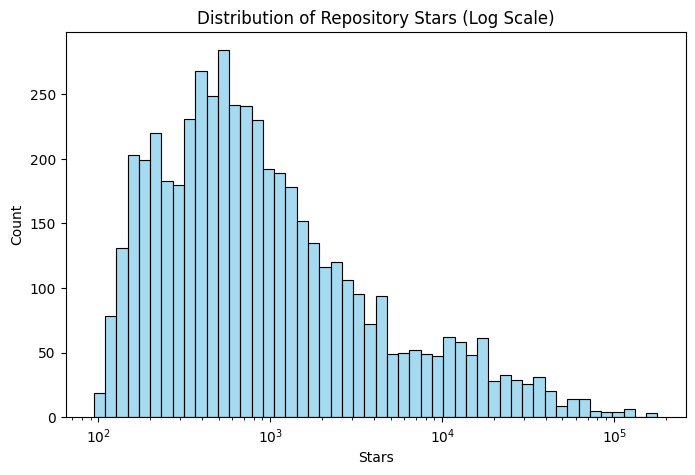

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df_cleaned['stars'].dropna(), bins=50, log_scale=True, color='skyblue')
plt.title("Distribution of Repository Stars (Log Scale)")
plt.xlabel("Stars")
plt.ylabel("Count")
plt.show()

Top 10 most common topics:
 machine-learning: 1378
ai: 778
 deep-learning: 772
 python: 743
 ai: 671
 llm: 637
 openai: 430
 pytorch: 415
 artificial-intelligence: 306
 chatgpt: 254


/tmp/ipython-input-2026645062.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_topics_df, x='topic', y='count', palette='viridis')


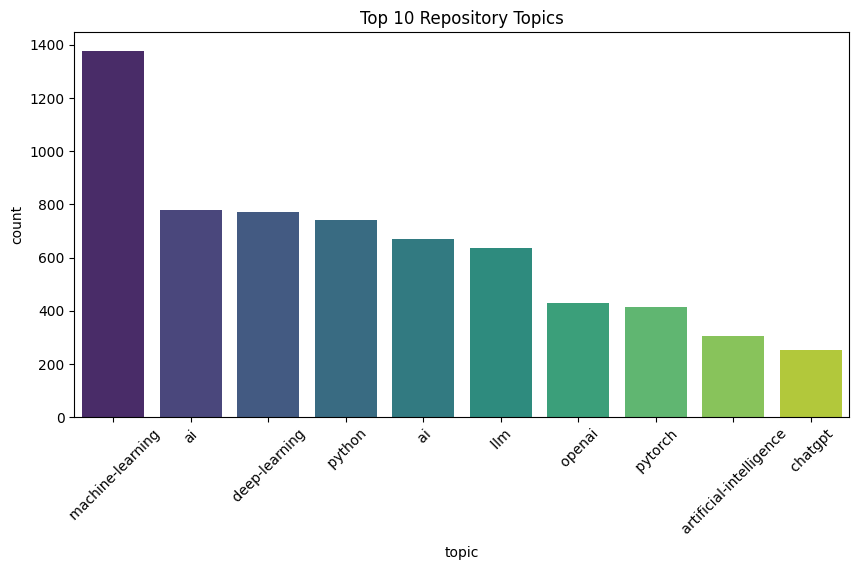

In [ ]:
from collections import Counter

# Drop NaN and split topics (assuming topics are stored as comma-separated strings)
all_topics = df_cleaned['topics'].dropna().str.split(',').sum()
topic_counts = Counter(all_topics)

# Most common topics
top_topics = topic_counts.most_common(10)
print("Top 10 most common topics:")
for topic, count in top_topics:
    print(f"{topic}: {count}")

# Optional: Bar plot
top_topics_df = pd.DataFrame(top_topics, columns=['topic', 'count'])
plt.figure(figsize=(10,5))
sns.barplot(data=top_topics_df, x='topic', y='count', palette='viridis')
plt.xticks(rotation=45)
plt.title("Top 10 Repository Topics")
plt.show()


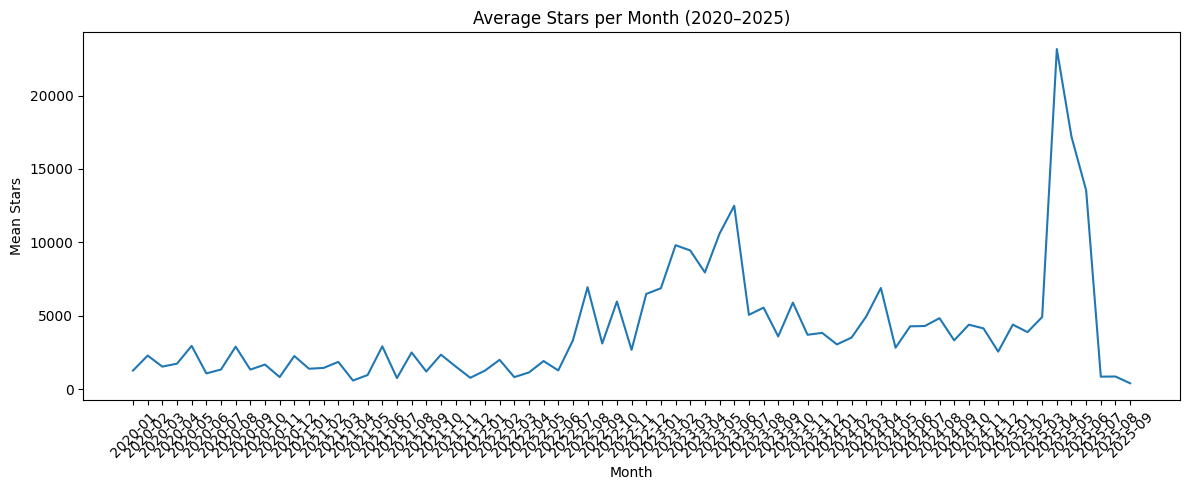

In [ ]:
# Group by month directly without adding a column
monthly_stars = (
    df_cleaned.groupby(df_cleaned["created_at"].dt.to_period("M"))["stars"]
      .mean()
      .reset_index()
)

monthly_stars["created_at"] = monthly_stars["created_at"].astype(str)

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_stars, x="created_at", y="stars")
plt.xticks(rotation=45)
plt.title("Average Stars per Month (2020–2025)")
plt.xlabel("Month")
plt.ylabel("Mean Stars")
plt.tight_layout()
plt.show()

### Top programming languages used

Top Primary langueges used

In [ ]:
# Replace "Jupyter Notebook" with "Python" in the primary_language column
df_cleaned['primary_language'] = df_cleaned['primary_language'].replace('Jupyter Notebook', 'Python')

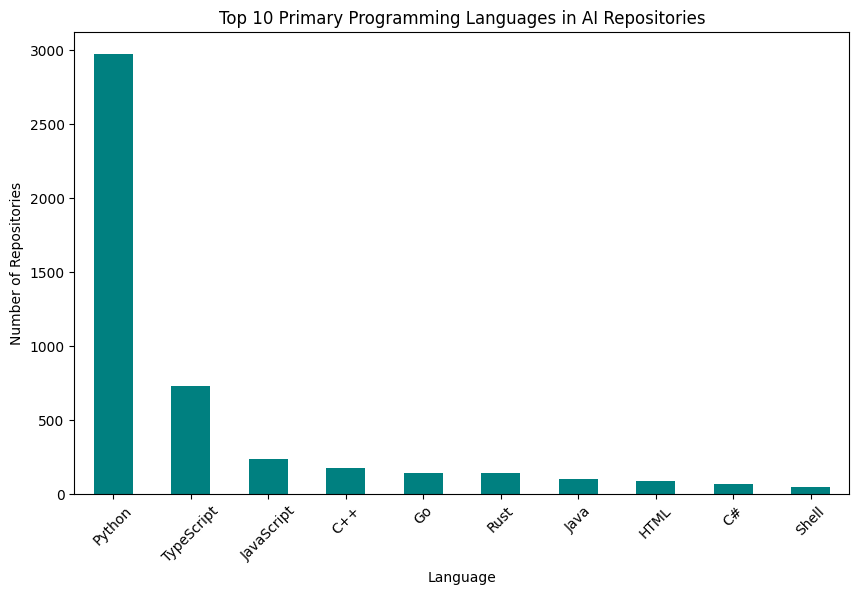

In [ ]:
plt.figure(figsize=(10,6))
df_cleaned['primary_language'].value_counts().head(10).plot(kind='bar', color='teal')
plt.title("Top 10 Primary Programming Languages in AI Repositories")
plt.xlabel("Language")
plt.ylabel("Number of Repositories")
plt.xticks(rotation=45)
plt.show()

Top all languages used

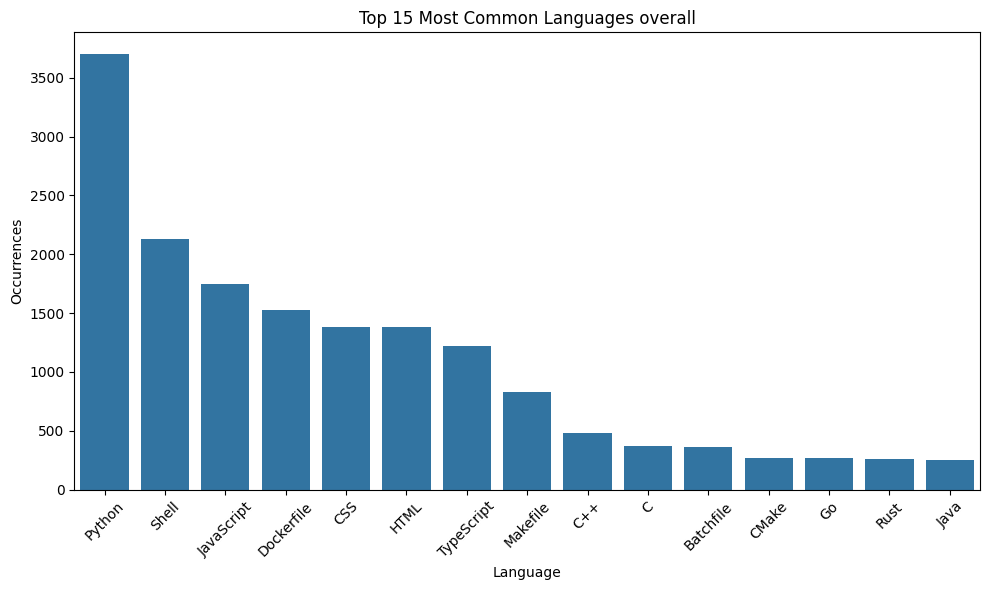

In [ ]:
from collections import Counter
import ast

lang_counter = Counter()

for entry in df_cleaned["all_languages_bytes"].dropna():
    try:
        langs = ast.literal_eval(entry)
        if isinstance(langs, dict):
          # Merge Jupyter Notebook into Python
            langs = {
                ("Python" if lang == "Jupyter Notebook" else lang): count
                for lang, count in langs.items()
            }
            lang_counter.update(langs.keys())
    except:
        continue

lang_freq = pd.DataFrame(lang_counter.items(), columns=["language", "count"]).sort_values(by="count", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=lang_freq.head(15), x="language", y="count")
plt.xticks(rotation=45)
plt.title("Top 15 Most Common Languages overall")
plt.xlabel("Language")
plt.ylabel("Occurrences")
plt.tight_layout()
plt.show()

Top languages used when python was the primary language

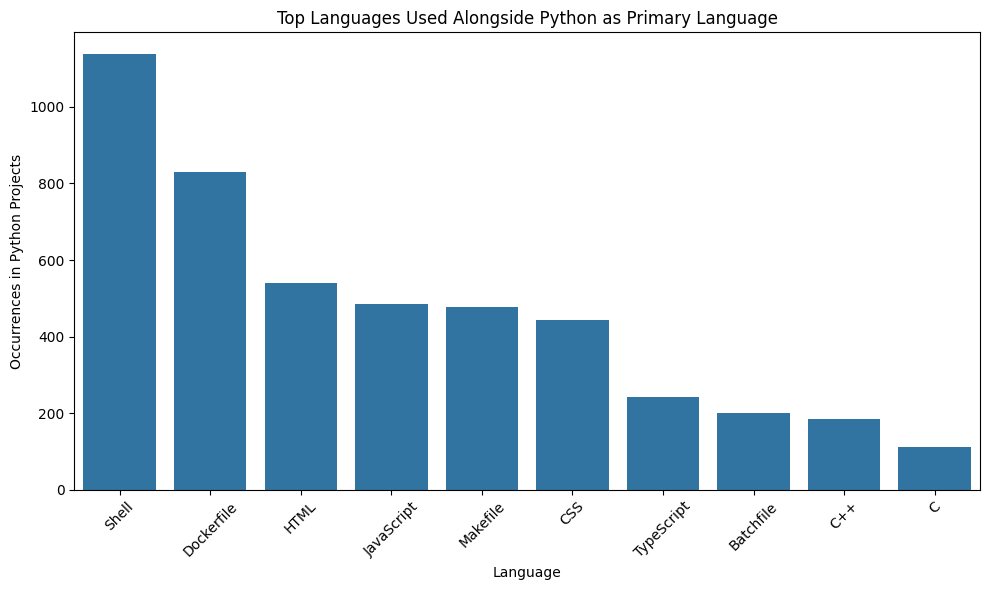

In [ ]:
import ast
from collections import Counter

# Filter only repositories where Python is the primary language
python_repos = df_cleaned[df_cleaned["primary_language"].str.lower() == "python"]

# Count co-occurring languages in the 'all_languages_bytes' column
lang_counter = Counter()

for entry in python_repos["all_languages_bytes"].dropna():
    try:
        langs = ast.literal_eval(entry)
        if isinstance(langs, dict):
          # Merge Jupyter Notebook into Python
            langs = {
                ("Python" if lang == "Jupyter Notebook" else lang): count
                for lang, count in langs.items()
            }
            lang_counter.update(langs.keys())
    except:
        continue

# Remove 'Python' itself to see other associated languages
if "Python" in lang_counter:
    del lang_counter["Python"]

lang_freq_py = (
    pd.DataFrame(lang_counter.items(), columns=["language", "count"])
    .sort_values(by="count", ascending=False)
)

plt.figure(figsize=(10,6))
sns.barplot(data=lang_freq_py.head(10), x="language", y="count")
plt.title("Top Languages Used Alongside Python as Primary Language")
plt.xticks(rotation=45)
plt.xlabel("Language")
plt.ylabel("Occurrences in Python Projects")
plt.tight_layout()
plt.show()

### Repositories created over time

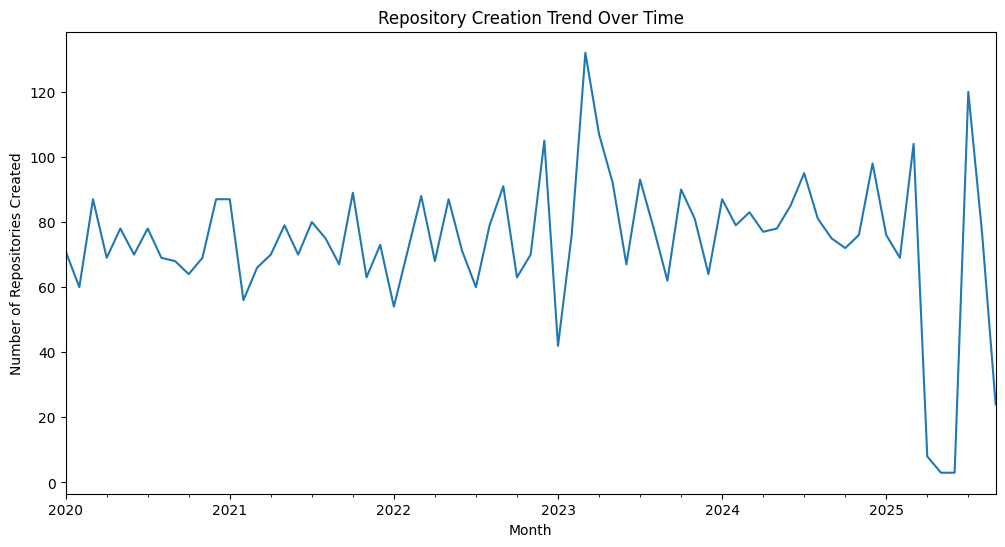

In [ ]:
warnings.filterwarnings('ignore', category=UserWarning)
df_cleaned['created_at'] = pd.to_datetime(df_cleaned['created_at'], errors='coerce')
plt.figure(figsize=(12,6))
df_cleaned['created_at'].dt.to_period("M").value_counts().sort_index().plot(kind='line')
plt.title("Repository Creation Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Repositories Created")
plt.show()

### Stars vs Forks scatter plot

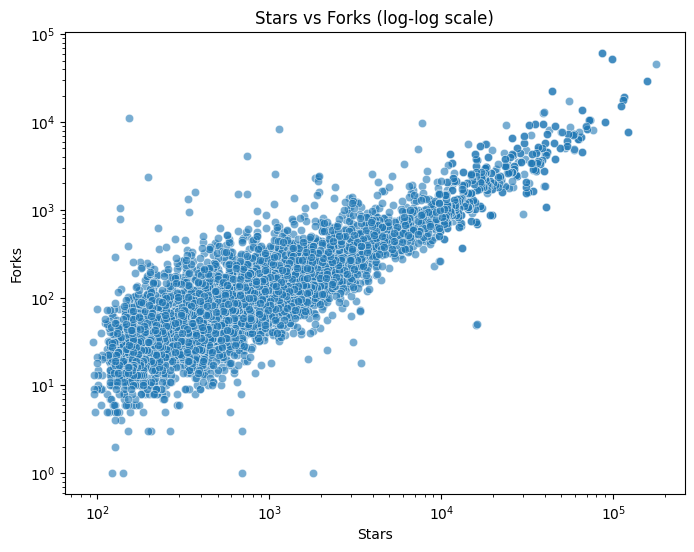

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_cleaned.dropna(subset=['stars', 'forks']), x='stars', y='forks', alpha=0.6)
plt.xscale('log')
plt.yscale('log')
plt.title("Stars vs Forks (log-log scale)")
plt.xlabel("Stars")
plt.ylabel("Forks")
plt.show()

In [ ]:
# Compute repository age in days
df_cleaned["repo_age_days"] = (df_cleaned["pushed_at"] - df_cleaned["created_at"]).dt.days

# Optional: also compute in years
df_cleaned["repo_age_years"] = df_cleaned["repo_age_days"] / 365

# Inspect
df_cleaned[["name", "repo_age_days", "stars", "forks"]].head()


,name,repo_age_days,stars,forks
0,DeepSpeed,2071.0,40213.0,4564.0
1,EasyOCR,1654.0,28016.0,3470.0
2,fastbook,1630.0,23807.0,9161.0
3,serve,1865.0,21746.0,2236.0
5,datasets,2008.0,20687.0,2953.0


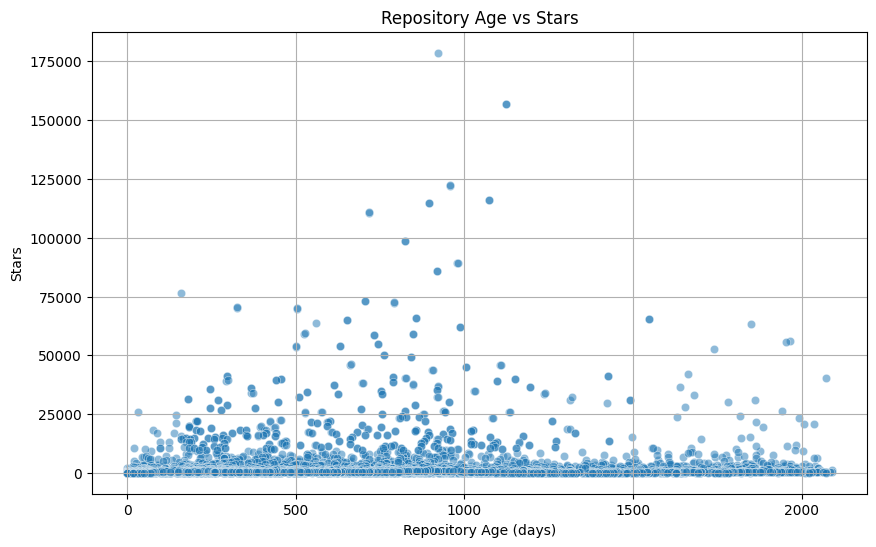

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.scatterplot(
    x="repo_age_days",
    y="stars",
    data=df_cleaned,
    alpha=0.5
)
plt.title("Repository Age vs Stars")
plt.xlabel("Repository Age (days)")
plt.ylabel("Stars")
plt.grid(True)
plt.show()


In [ ]:
correlation = df_cleaned["repo_age_days"].corr(df_cleaned["stars"])
print(f"Correlation between repository age and stars: {correlation:.3f}")


Correlation between repository age and stars: 0.023
